In [28]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [29]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [30]:
ts = pd.read_csv('MOD-00689.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31T18:59:05Z,6.743,0.692,0.187,0.038,0.031,0.020,5.052,775.946,38.903,2.402,29.938,49.6,0.5
1,2025-12-31T18:58:05Z,7.506,0.821,0.251,0.027,0.042,0.015,5.551,768.897,39.248,2.401,29.223,49.7,0.5
2,2025-12-31T18:57:05Z,7.911,0.835,0.231,0.051,0.034,0.015,5.909,760.097,39.248,2.480,29.449,49.8,0.4
3,2025-12-31T18:56:05Z,7.611,0.901,0.256,0.050,0.030,0.010,5.451,784.175,38.185,2.519,29.677,50.0,0.4
4,2025-12-31T18:55:05Z,8.115,0.936,0.324,0.078,0.046,0.012,4.781,774.804,38.190,2.519,30.155,49.9,0.4


In [31]:
start = ts['timestamp_local'].min()
print(start)

2025-03-31T20:00:58Z


In [32]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31 18:59:05,6.743,0.692,0.187,0.038,0.031,0.020,5.052,775.946,38.903,2.402,29.938,49.6,0.5
1,2025-12-31 18:58:05,7.506,0.821,0.251,0.027,0.042,0.015,5.551,768.897,39.248,2.401,29.223,49.7,0.5
2,2025-12-31 18:57:05,7.911,0.835,0.231,0.051,0.034,0.015,5.909,760.097,39.248,2.480,29.449,49.8,0.4
3,2025-12-31 18:56:05,7.611,0.901,0.256,0.050,0.030,0.010,5.451,784.175,38.185,2.519,29.677,50.0,0.4
4,2025-12-31 18:55:05,8.115,0.936,0.324,0.078,0.046,0.012,4.781,774.804,38.190,2.519,30.155,49.9,0.4


## Full Timeseries Plot

In [33]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31,22.607458,3.860975,1.386379,0.414579,0.527083,0.400654,9.236329,831.013317,50.169733,2.252729,25.180992,83.506250,16.645417
2025-04-01,5.982742,0.944217,0.305519,0.073523,0.076156,0.049683,3.479537,656.651970,57.429887,2.114332,10.378480,42.757847,13.793472
2025-04-02,4.536479,0.653490,0.347128,0.140185,0.195326,0.151458,4.166426,718.626922,61.246373,1.997671,17.258922,40.127292,9.196250
2025-04-03,21.171658,2.612645,0.952415,0.348959,0.517942,0.428569,11.615153,842.587770,45.299719,2.038467,22.413690,75.148472,16.122639
2025-04-04,6.449088,1.038488,0.570583,0.240577,0.446801,0.466658,13.455104,737.878446,50.823744,2.131840,13.179772,43.965740,21.481584


In [34]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-03-31,22.607458,3.860975,1.386379,0.414579,0.527083,0.400654,9.236329,831.013317,50.169733,2.252729,25.180992,83.506250,16.645417,6.051511
2025-04-01,5.982742,0.944217,0.305519,0.073523,0.076156,0.049683,3.479537,656.651970,57.429887,2.114332,10.378480,42.757847,13.793472,4.451137
2025-04-02,4.536479,0.653490,0.347128,0.140185,0.195326,0.151458,4.166426,718.626922,61.246373,1.997671,17.258922,40.127292,9.196250,4.648616
2025-04-03,21.171658,2.612645,0.952415,0.348959,0.517942,0.428569,11.615153,842.587770,45.299719,2.038467,22.413690,75.148472,16.122639,7.777935
2025-04-04,6.449088,1.038488,0.570583,0.240577,0.446801,0.466658,13.455104,737.878446,50.823744,2.131840,13.179772,43.965740,21.481584,10.678461


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3562/3981048099.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)


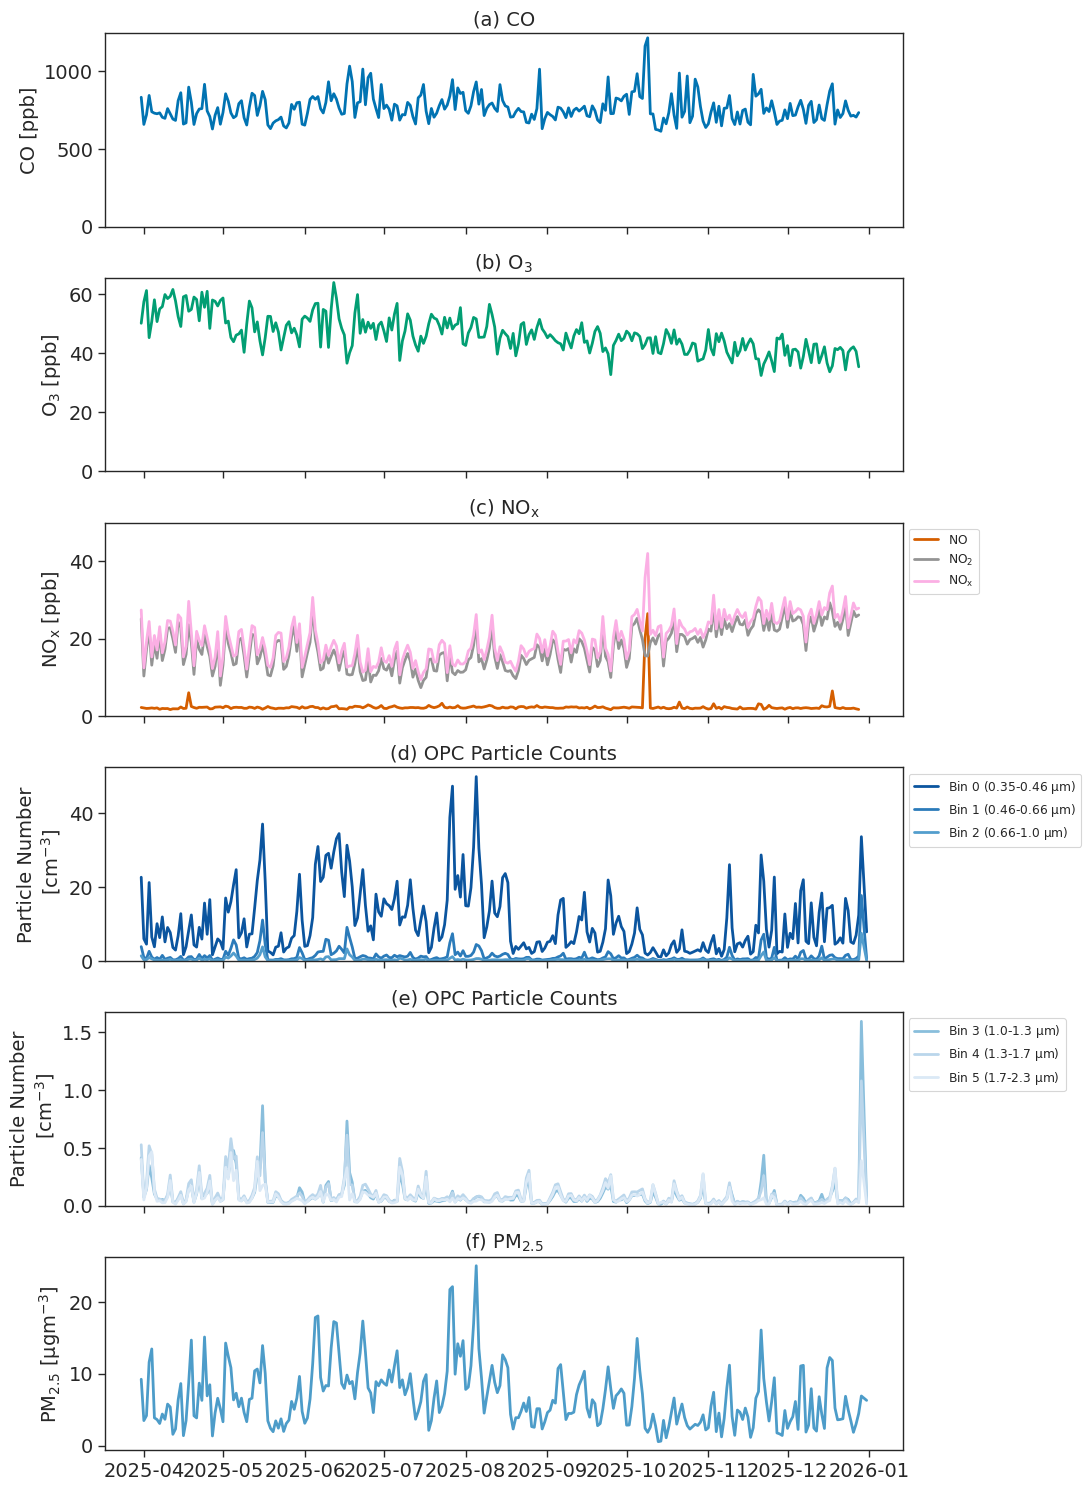

In [35]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

fig.savefig('timeseries_MOD-00689.png')

## Dirunal Plots

In [36]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31 20:00:00,20.768583,2.289800,1.139267,0.441000,0.632867,0.495017,11.479567,834.614833,42.491533,1.830967,28.182517,76.388333,16.728333
2025-03-31 21:00:00,27.621067,3.760017,1.450267,0.479683,0.665117,0.547983,11.697033,901.422433,44.939900,2.303900,32.650583,84.800000,16.403333
2025-03-31 22:00:00,23.717233,4.488867,1.469967,0.404783,0.477200,0.356817,8.083050,847.245133,52.687350,2.449300,25.185133,86.758333,16.781667
2025-03-31 23:00:00,18.322950,4.905217,1.486017,0.332850,0.333150,0.202800,5.685667,740.770867,60.560150,2.426750,14.705733,86.078333,16.668333
2025-04-01 00:00:00,17.158617,3.367217,0.975250,0.224817,0.231167,0.147750,4.965000,687.761883,63.824250,2.296133,13.213117,84.556667,16.410000


In [37]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-03-31 20:00:00,20.768583,2.289800,1.139267,0.441000,0.632867,0.495017,11.479567,834.614833,42.491533,1.830967,28.182517,76.388333,16.728333,8.201648
2025-03-31 21:00:00,27.621067,3.760017,1.450267,0.479683,0.665117,0.547983,11.697033,901.422433,44.939900,2.303900,32.650583,84.800000,16.403333,8.452083
2025-03-31 22:00:00,23.717233,4.488867,1.469967,0.404783,0.477200,0.356817,8.083050,847.245133,52.687350,2.449300,25.185133,86.758333,16.781667,7.441032
2025-03-31 23:00:00,18.322950,4.905217,1.486017,0.332850,0.333150,0.202800,5.685667,740.770867,60.560150,2.426750,14.705733,86.078333,16.668333,6.704625
2025-04-01 00:00:00,17.158617,3.367217,0.975250,0.224817,0.231167,0.147750,4.965000,687.761883,63.824250,2.296133,13.213117,84.556667,16.410000,6.440430


In [38]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-03-31 20:00:00,20.768583,2.289800,1.139267,0.441000,0.632867,0.495017,11.479567,834.614833,42.491533,1.830967,28.182517,76.388333,16.728333,8.201648,20
2025-03-31 21:00:00,27.621067,3.760017,1.450267,0.479683,0.665117,0.547983,11.697033,901.422433,44.939900,2.303900,32.650583,84.800000,16.403333,8.452083,21
2025-03-31 22:00:00,23.717233,4.488867,1.469967,0.404783,0.477200,0.356817,8.083050,847.245133,52.687350,2.449300,25.185133,86.758333,16.781667,7.441032,22
2025-03-31 23:00:00,18.322950,4.905217,1.486017,0.332850,0.333150,0.202800,5.685667,740.770867,60.560150,2.426750,14.705733,86.078333,16.668333,6.704625,23
2025-04-01 00:00:00,17.158617,3.367217,0.975250,0.224817,0.231167,0.147750,4.965000,687.761883,63.824250,2.296133,13.213117,84.556667,16.410000,6.440430,0


In [39]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,10.823466,1.486931,0.423238,0.092818,0.100767,0.072805,6.261321,754.381085,45.421374,2.097259,19.100481,60.543340,17.281623,6.293995
01:00,11.071481,1.450180,0.394911,0.087354,0.097823,0.072728,6.189915,740.889967,44.660451,2.034372,18.674177,61.942991,16.879444,6.286199
02:00,11.165562,1.389493,0.377979,0.086356,0.097371,0.072719,6.024420,729.199492,43.890829,2.018238,18.826555,63.250963,16.502457,6.249423
03:00,11.281036,1.401254,0.375089,0.086222,0.097986,0.073780,5.948670,724.711035,43.127810,2.010532,18.631253,64.306511,16.158747,6.234997
04:00,11.448686,1.430031,0.382890,0.089435,0.100352,0.072843,5.878032,715.939351,42.476240,1.998521,18.701489,65.386556,15.866344,6.225248
05:00,11.662532,1.502400,0.415730,0.096829,0.105958,0.075674,5.940023,730.824987,41.104908,1.981385,19.239895,66.365871,15.619104,6.254863
06:00,11.883599,1.523215,0.420642,0.098758,0.109964,0.080798,6.139453,750.741810,39.878346,2.139909,20.280586,66.887555,15.476340,6.319675
07:00,11.926825,1.523667,0.437431,0.107233,0.125750,0.095868,6.576389,799.827355,40.031639,2.488649,20.144074,65.332542,15.877181,6.432604
08:00,11.469220,1.350567,0.371006,0.089310,0.109837,0.084862,6.785204,786.258872,40.834530,2.500220,17.576639,60.738265,17.359126,6.458665


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3562/46387781.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_3562/46387781.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r",

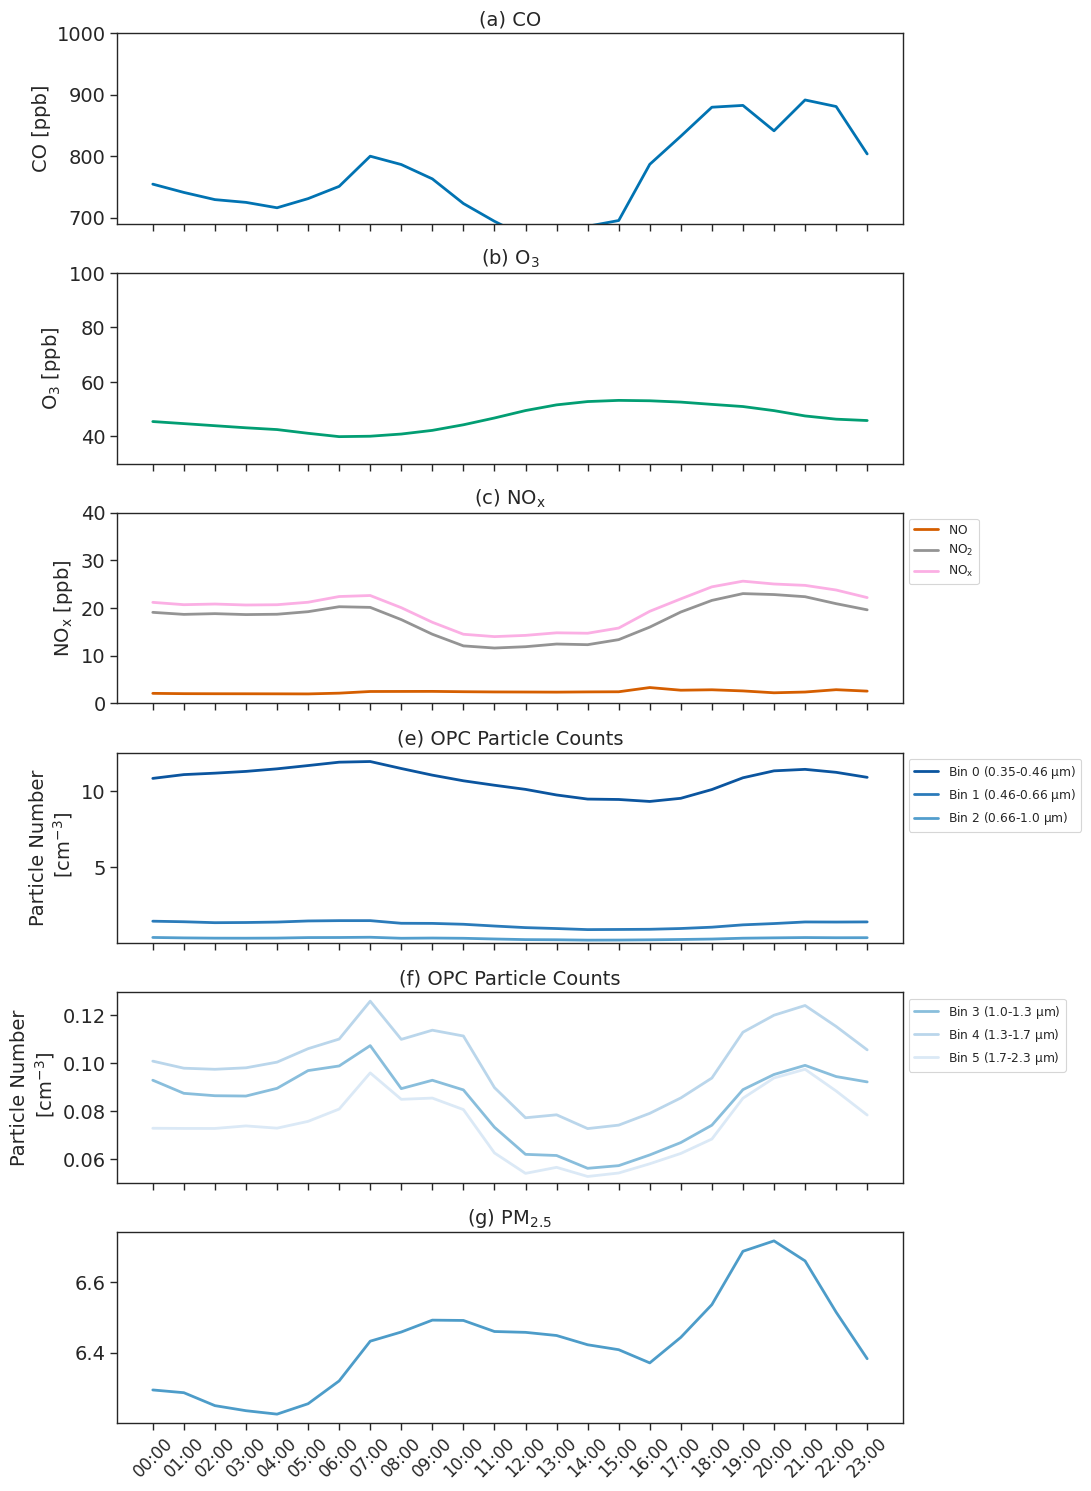

In [40]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 1000)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(30, 100)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 40)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.05, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)


# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

fig.savefig('dirunal_MOD-00689_allfeatures.png')

## Diurnal by Season

In [41]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [42]:
ts_hour = ts_hour.reset_index()

In [43]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-03-31 20:00:00,20.768583,2.289800,1.139267,0.441000,0.632867,0.495017,11.479567,834.614833,42.491533,1.830967,28.182517,76.388333,16.728333,8.201648,20,Spring
1,2025-03-31 21:00:00,27.621067,3.760017,1.450267,0.479683,0.665117,0.547983,11.697033,901.422433,44.939900,2.303900,32.650583,84.800000,16.403333,8.452083,21,Spring
2,2025-03-31 22:00:00,23.717233,4.488867,1.469967,0.404783,0.477200,0.356817,8.083050,847.245133,52.687350,2.449300,25.185133,86.758333,16.781667,7.441032,22,Spring
3,2025-03-31 23:00:00,18.322950,4.905217,1.486017,0.332850,0.333150,0.202800,5.685667,740.770867,60.560150,2.426750,14.705733,86.078333,16.668333,6.704625,23,Spring
4,2025-04-01 00:00:00,17.158617,3.367217,0.975250,0.224817,0.231167,0.147750,4.965000,687.761883,63.824250,2.296133,13.213117,84.556667,16.410000,6.440430,0,Spring


In [44]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                                
Autumn 0      6.244459  0.950252  0.317157  0.071127  0.077903  0.059056   
       1      6.567629  0.824043  0.258808  0.060501  0.072021  0.059250   
       2      6.703728  0.789909  0.248042  0.059861  0.073264  0.061193   
       3      7.059896  0.830163  0.254323  0.061179  0.074750  0.063159   
       4      7.338429  0.798398  0.219568  0.051118  0.063454  0.054294   
...                ...       ...       ...       ...       ...       ...   
Winter 19    10.589108  1.200627  0.335833  0.061327  0.060888  0.039459   
       20    11.025101  1.243409  0.340560  0.062107  0.060419  0.040918   
       21    10.914479  1.247496  0.331162  0.060028  0.059111  0.040333   
       22    11.051841  1.269374  0.325090  0.060233  0.059923  0.041169   
       23    11.754010  1.478452  0.355486  0.063814  0.062038  0.044475   

                 pm25          co         o3        no        no2         rh  \
Season Hour                                                                    
Autumn 0     4.718197  735.731761  42.369392  2.077313  21.123007  59.626237   
       1     4.707205  727.647143  41.362470  1.938201  20.804934  61.497350   
       2     4.648632  718.740693  40.866475  1.930512  20.762081  62.974757   
       3     4.665772  717.207361  40.216719  1.949065  21.412097  64.140263   
       4     4.522401  707.174125  39.671108  1.936590  21.209505  65.241854   
...               ...         ...        ...       ...        ...        ...   
Winter 19    5.782714  764.115456  39.193340  1.969229  27.388324  54.271358   
       20    5.891032  765.437681  38.832961  2.032899  27.129265  55.041667   
       21    5.792796  770.059244  38.581245  2.076343  26.971109  55.743827   
       22    5.456028  752.432694  38.501588  2.085190  26.700890  57.148642   
       23    5.319411  738.552827  38.480828  2.113801  26.565752  58.565802   

                  temp    pm25_c  
Season Hour                       
Autumn 0     15.693743  5.732739  
       1     15.248614  5.752114  
       2     14.874419  5.751408  
       3     14.550070  5.768270  
       4     14.303931  5.739676  
...                ...       ...  
Winter 19     2.790309  5.276277  
       20     2.498457  5.312450  
       21     2.293765  5.289793  
       22     2.087160  5.212822  
       23     1.845370  5.194032  

[96 rows x 14 columns]

In [45]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,6.244459,0.950252,0.317157,0.071127,0.077903,0.059056,4.718197,735.731761,42.369392,2.077313,21.123007,59.626237,15.693743,5.732739
1,Autumn,1,6.567629,0.824043,0.258808,0.060501,0.072021,0.059250,4.707205,727.647143,41.362470,1.938201,20.804934,61.497350,15.248614,5.752114
2,Autumn,2,6.703728,0.789909,0.248042,0.059861,0.073264,0.061193,4.648632,718.740693,40.866475,1.930512,20.762081,62.974757,14.874419,5.751408
3,Autumn,3,7.059896,0.830163,0.254323,0.061179,0.074750,0.063159,4.665772,717.207361,40.216719,1.949065,21.412097,64.140263,14.550070,5.768270
4,Autumn,4,7.338429,0.798398,0.219568,0.051118,0.063454,0.054294,4.522401,707.174125,39.671108,1.936590,21.209505,65.241854,14.303931,5.739676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,10.589108,1.200627,0.335833,0.061327,0.060888,0.039459,5.782714,764.115456,39.193340,1.969229,27.388324,54.271358,2.790309,5.276277
92,Winter,20,11.025101,1.243409,0.340560,0.062107,0.060419,0.040918,5.891032,765.437681,38.832961,2.032899,27.129265,55.041667,2.498457,5.312450
93,Winter,21,10.914479,1.247496,0.331162,0.060028,0.059111,0.040333,5.792796,770.059244,38.581245,2.076343,26.971109,55.743827,2.293765,5.289793
94,Winter,22,11.051841,1.269374,0.325090,0.060233,0.059923,0.041169,5.456028,752.432694,38.501588,2.085190,26.700890,57.148642,2.087160,5.212822


In [46]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [47]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,6.244459,0.950252,0.317157,0.071127,0.077903,0.059056,4.718197,735.731761,42.369392,2.077313,21.123007,59.626237,15.693743,5.732739
01:00,Autumn,1,6.567629,0.824043,0.258808,0.060501,0.072021,0.059250,4.707205,727.647143,41.362470,1.938201,20.804934,61.497350,15.248614,5.752114
02:00,Autumn,2,6.703728,0.789909,0.248042,0.059861,0.073264,0.061193,4.648632,718.740693,40.866475,1.930512,20.762081,62.974757,14.874419,5.751408
03:00,Autumn,3,7.059896,0.830163,0.254323,0.061179,0.074750,0.063159,4.665772,717.207361,40.216719,1.949065,21.412097,64.140263,14.550070,5.768270
04:00,Autumn,4,7.338429,0.798398,0.219568,0.051118,0.063454,0.054294,4.522401,707.174125,39.671108,1.936590,21.209505,65.241854,14.303931,5.739676
05:00,Autumn,5,7.730916,0.903206,0.251295,0.056246,0.065866,0.054625,4.549838,726.360268,38.594569,1.947102,21.813492,66.569004,14.077375,5.768376
06:00,Autumn,6,8.221121,1.055199,0.296349,0.064310,0.071211,0.056743,4.704502,738.798475,36.953886,2.138728,22.887075,67.764264,13.788334,5.828701
07:00,Autumn,7,8.394103,0.975112,0.270693,0.061104,0.071983,0.058475,4.935426,770.622102,37.219678,2.101830,23.166891,66.943221,14.053408,5.891065
08:00,Autumn,8,8.008887,0.874715,0.255167,0.061175,0.076745,0.062027,5.326646,785.712180,37.818421,2.181126,19.764575,62.229232,15.676779,5.975681
09:00,Autumn,9,6.863359,0.777991,0.242329,0.059378,0.077010,0.060017,5.386445,746.191776,38.561929,2.386455,15.036722,52.632060,18.848390,5.921750


In [48]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3562/2680340984.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_3562/2680340984.py:41: SyntaxWarning: invalid escape sequence '\m

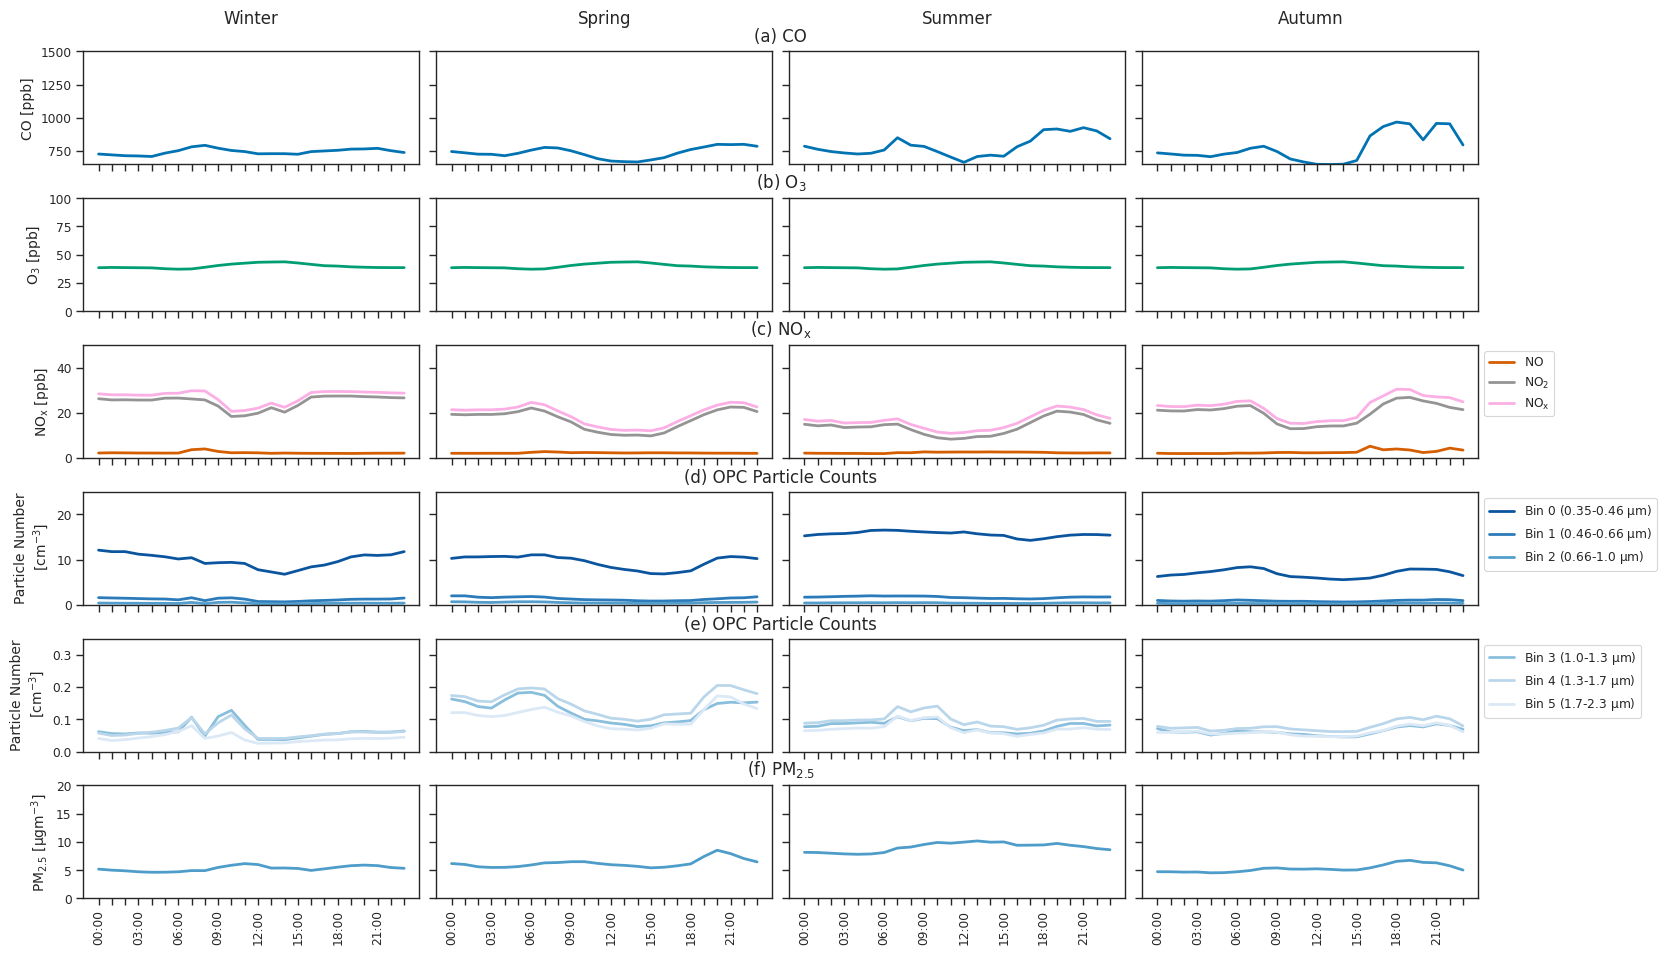

In [49]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 1500)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 100)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticklabels(['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''], rotation=90)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

fig.savefig('diurnal_by_season_MOD-00689.png')